<a href="https://colab.research.google.com/github/busetas/Roketsan_Sensor/blob/main/05_Sens%C3%B6r_ve_Platform_Body_Eksenleri.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Bir platform ve buna takılı olan bir sensör olsun. Sensör, platform üzerinde açı yapacak bir şekilde duruyor olsun. Sensör kendisine göre mesafe ve açı ölçüyor olsun. Sensör ölçümlerinin platformun body eksenine göre dönüşümlerini gerçekleştiren formülasyonu yapalım.

-------------------------------

Sensörün ölçtüğü dikey mesafe (range) $r$ ve açı $\theta$ değerlerini, sensörün platform üzerindeki mounting (montaj) konumunu ve oryantasyon açısını hesaba katarak Platform Body ($B$) eksen takımına dönüştürmek için dönme matrisi (rotation matrix) ve öteleme (translation) vektörü kullanılır.


**Matematiksel Formülasyon**

Sensörün kendi lokal ekseni ($S$) ile Platform Body ekseni ($B$) arasındaki ilişkiyi ifade edelim:

1. Sensörün Kendi Lokal Eksenindeki Ölçüm ($S$ Eksen Takımı)

Sensörün ölçtüğü mesafe $r$ ve hedef açı $\theta$ (sensör eksenine göre sapma açısı) olsun. Sensör lokal ekseninde hedefin konumu ($P^S$):$$P^S = \begin{bmatrix} x_s \\ y_s \\ z_s \end{bmatrix} = \begin{bmatrix} r \cdot \cos(\theta) \\ r \cdot \sin(\theta) \\ 0 \end{bmatrix}$$(Açı ölçümü 2D düzlemde kabul edilmiştir. 3D polar ölçümler için $\phi$ gibi ikinci bir açı eklenebilir.)

2. Sensörün Platforma Göre Konumu ve OryantasyonuÖteleme Vektörü ($T_B^S$):

Sensörün platform orijinine ($B$) göre konumu:$$T_B^S = \begin{bmatrix} x_{off} \\ y_{off} \\ z_{off} \end{bmatrix}$$Dönme Açıları: Sensör platforma göre $\psi$ (yaw), $\theta_{mount}$ (pitch) ve $\phi_{mount}$ (roll) açılarıyla takılmış olsun. 2D yönelim farkı $\alpha$ (sensörün bakış açısı sapması) için dönme matrisi ($R_B^S$):$$R_B^S = \begin{bmatrix} \cos(\alpha) & -\sin(\alpha) & 0 \\ \sin(\alpha) & \cos(\alpha) & 0 \\ 0 & 0 & 1 \end{bmatrix}$$

3. Platform Body Eksenine Dönüşüm ($P^B$)

Sensör koordinatlarındaki bir noktayı Platform Body eksenine taşımak için öteleme ve dönme işlemleri uygulanır:$$P^B = R_B^S \cdot P^S + T_B^S$$Açık formda (2D düzlemde):$$\begin{bmatrix} X_B \\ Y_B \end{bmatrix} = \begin{bmatrix} \cos(\alpha) & -\sin(\alpha) \\ \sin(\alpha) & \cos(\alpha) \end{bmatrix} \begin{bmatrix} r \cdot \cos(\theta) \\ r \cdot \sin(\theta) \end{bmatrix} + \begin{bmatrix} x_{off} \\ y_{off} \end{bmatrix}$$Açıların toplamı prensibiyle ifade edilirse:$$X_B = r \cdot \cos(\theta + \alpha) + x_{off}$$$$Y_B = r \cdot \sin(\theta + \alpha) + y_{off}$$

In [1]:
import numpy as np

def sensor_to_body_transformation_detailed(r, theta_deg, alpha_deg, x_off, y_off, z_off=0.0):
    """
    Sensör ölçümlerini Platform Body eksenine adım adım dönüştürür ve konsola yazdırır.
    """
    print("=" * 60)
    print("                KOORDİNAT DÖNÜŞÜM ADIMLARI")
    print("=" * 60)

    # Radians dönüşümleri
    theta_rad = np.radians(theta_deg)
    alpha_rad = np.radians(alpha_deg)

    # -------------------------------------------------------------
    # ADIM 1: SENSÖR LOKAL EKSENİNDE HEDEF HESABI (Polar -> Kartezyen)
    # -------------------------------------------------------------
    x_s = r * np.cos(theta_rad)
    y_s = r * np.sin(theta_rad)
    z_s = 0.0
    P_S = np.array([x_s, y_s, z_s])

    print("\n[ADIM 1] SENSÖRÜN KENDİ ÖLÇÜMÜ (Sensör Lokal Eksen Takımı - S)")
    print(f"  • Ölçülen Mesafe (r)            : {r:.2f} m")
    print(f"  • Sensöre Göre Hedef Açısı (θ)  : {theta_deg:.2f}° ({theta_rad:.4f} rad)")
    print(f"  • Sensör Ekseninde Konum (P_S)   : X_s = {x_s:.3f} m, Y_s = {y_s:.3f} m, Z_s = {z_s:.3f} m")

    # -------------------------------------------------------------
    # ADIM 2: MONTAJ BİLGİLERİ VE DÖNME MATRİSİ (Yönelim Hesabı)
    # -------------------------------------------------------------
    R_B_S = np.array([
        [np.cos(alpha_rad), -np.sin(alpha_rad), 0.0],
        [np.sin(alpha_rad),  np.cos(alpha_rad), 0.0],
        [0.0,                0.0,               1.0]
    ])

    # Sadece dönme uygulanmış (ötelemesiz) konum
    P_rot = np.dot(R_B_S, P_S)

    # Toplam bakış açısı (Sensör açısı + Montaj açısı)
    total_angle_deg = theta_deg + alpha_deg

    print("\n[ADIM 2] SENSÖR MONTAJ VE DÖNME (ROTASYON) İŞLEMİ")
    print(f"  • Sensör Montaj Açısı (α)       : {alpha_deg:.2f}° ({alpha_rad:.4f} rad)")
    print(f"  • Sensör Montaj Konumu (T_B_S)   : X_off = {x_off:.2f} m, Y_off = {y_off:.2f} m, Z_off = {z_off:.2f} m")
    print(f"  • Platforma Göre Toplam Açı     : θ + α = {total_angle_deg:.2f}°")
    print(f"  • Dönme Matrisi (R_B_S):\n{R_B_S}")
    print(f"  • Sadece Döndürülmüş Konum (R * P_S): X = {P_rot[0]:.3f} m, Y = {P_rot[1]:.3f} m, Z = {P_rot[2]:.3f} m")

    # -------------------------------------------------------------
    # ADIM 3: ÖTELEME İLE PLATFORM BODY EKSENİNE GEÇİŞ
    # -------------------------------------------------------------
    T_B_S = np.array([x_off, y_off, z_off])
    P_B = P_rot + T_B_S

    # Platform orijinine göre hedefin toplam mesafesi ve açısı
    r_body = np.linalg.norm(P_B)
    theta_body_deg = np.degrees(np.arctan2(P_B[1], P_B[0]))

    print("\n[ADIM 3] PLATFORM BODY EKSENİNE TAŞIMA (ÖTELEME VE SONUÇ)")
    print(f"  • Öteleme Vektörü Eklendi (P_B = R*P_S + T_B_S)")
    print(f"  • Platform Ekseninde Hedef (P_B): X_b = {P_B[0]:.3f} m, Y_b = {P_B[1]:.3f} m, Z_b = {P_B[2]:.3f} m")
    print("  --------------------------------------------------")
    print(f"  • Platform Merkezine Göre Toplam Mesafe (r_body) : {r_body:.3f} m")
    print(f"  • Platform X Eksenine Göre Açı (θ_body)        : {theta_body_deg:.3f}°")
    print("=" * 60 + "\n")

    return P_B

# --- ÖRNEK ÇALIŞTIRMA ---
if __name__ == "__main__":
    # Senaryo Parametreleri:
    r_olcum = 10.0       # Sensör 10 metre mesafe okuyor
    theta_olcum = 15.0   # Sensör kendi 15 derece solunda hedef görüyor

    alpha_montaj = -30.0 # Sensör gövdeye 30 derece sağa yatık monte edilmiş
    x_offset = 1.5       # Sensör platformun 1.5m önünde
    y_offset = -0.5      # Sensör platformun 0.5m sağında

    P_final = sensor_to_body_transformation_detailed(
        r=r_olcum,
        theta_deg=theta_olcum,
        alpha_deg=alpha_montaj,
        x_off=x_offset,
        y_off=y_offset
    )

                KOORDİNAT DÖNÜŞÜM ADIMLARI

[ADIM 1] SENSÖRÜN KENDİ ÖLÇÜMÜ (Sensör Lokal Eksen Takımı - S)
  • Ölçülen Mesafe (r)            : 10.00 m
  • Sensöre Göre Hedef Açısı (θ)  : 15.00° (0.2618 rad)
  • Sensör Ekseninde Konum (P_S)   : X_s = 9.659 m, Y_s = 2.588 m, Z_s = 0.000 m

[ADIM 2] SENSÖR MONTAJ VE DÖNME (ROTASYON) İŞLEMİ
  • Sensör Montaj Açısı (α)       : -30.00° (-0.5236 rad)
  • Sensör Montaj Konumu (T_B_S)   : X_off = 1.50 m, Y_off = -0.50 m, Z_off = 0.00 m
  • Platforma Göre Toplam Açı     : θ + α = -15.00°
  • Dönme Matrisi (R_B_S):
[[ 0.8660254  0.5        0.       ]
 [-0.5        0.8660254  0.       ]
 [ 0.         0.         1.       ]]
  • Sadece Döndürülmüş Konum (R * P_S): X = 9.659 m, Y = -2.588 m, Z = 0.000 m

[ADIM 3] PLATFORM BODY EKSENİNE TAŞIMA (ÖTELEME VE SONUÇ)
  • Öteleme Vektörü Eklendi (P_B = R*P_S + T_B_S)
  • Platform Ekseninde Hedef (P_B): X_b = 11.159 m, Y_b = -3.088 m, Z_b = 0.000 m
  --------------------------------------------------
  • Pl

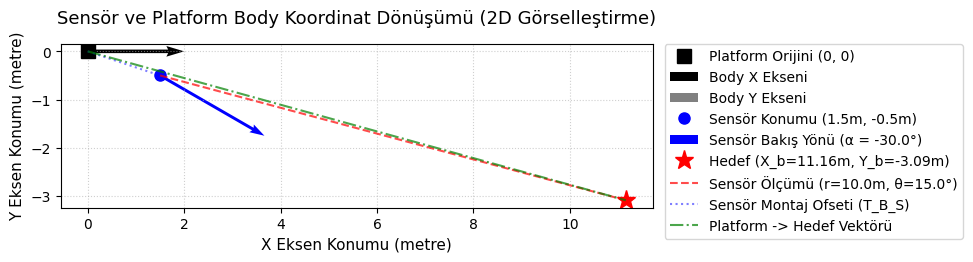

In [2]:
import matplotlib.pyplot as plt
import numpy as np

def plot_sensor_body_transformation(r, theta_deg, alpha_deg, x_off, y_off):
    # Radians dönüşümleri
    theta_rad = np.radians(theta_deg)
    alpha_rad = np.radians(alpha_deg)

    # 1. Sensör lokal eksenindeki hedef konumu
    x_s = r * np.cos(theta_rad)
    y_s = r * np.sin(theta_rad)

    # 2. Dönme matrisi uygulaması
    R = np.array([
        [np.cos(alpha_rad), -np.sin(alpha_rad)],
        [np.sin(alpha_rad),  np.cos(alpha_rad)]
    ])

    # 3. Öteleme ile Platform Body Eksenindeki Hedef Konumu (P_B)
    P_rot = np.dot(R, np.array([x_s, y_s]))
    x_b = P_rot[0] + x_off
    y_b = P_rot[1] + y_off

    # --- ÇİZİM İŞLEMLERİ ---
    fig, ax = plt.subplots(figsize=(10, 8))

    # Platform Orijini (Body Center)
    ax.plot(0, 0, 'ks', markersize=10, label='Platform Orijini (0, 0)')

    # Body Eksen Vektörleri (X_B ve Y_B)
    ax.quiver(0, 0, 2, 0, angles='xy', scale_units='xy', scale=1, color='black', width=0.006, label='Body X Ekseni')
    ax.quiver(0, 0, 0, 2, angles='xy', scale_units='xy', scale=1, color='gray', width=0.006, label='Body Y Ekseni')

    # Sensörün Platform Üzerindeki Konumu
    ax.plot(x_off, y_off, 'bo', markersize=8, label=f'Sensör Konumu ({x_off}m, {y_off}m)')

    # Sensör Sıfır Derece Bakış Eksen Vektörü (Açılandırılmış)
    sensor_dir_x = np.cos(alpha_rad) * 2.5
    sensor_dir_y = np.sin(alpha_rad) * 2.5
    ax.quiver(x_off, y_off, sensor_dir_x, sensor_dir_y, angles='xy', scale_units='xy', scale=1, color='blue', width=0.005, label=f'Sensör Bakış Yönü (α = {alpha_deg}°)')

    # Hedef Noktası
    ax.plot(x_b, y_b, 'r*', markersize=14, label=f'Hedef (X_b={x_b:.2f}m, Y_b={y_b:.2f}m)')

    # Çizgiler / Bağlantılar
    # Sensör -> Hedef
    ax.plot([x_off, x_b], [y_off, y_b], 'r--', alpha=0.7, label=f'Sensör Ölçümü (r={r}m, θ={theta_deg}°)')
    # Platform -> Sensör
    ax.plot([0, x_off], [0, y_off], 'b:', alpha=0.5, label='Sensör Montaj Ofseti (T_B_S)')
    # Platform -> Hedef
    ax.plot([0, x_b], [0, y_b], 'g-.', alpha=0.7, label='Platform -> Hedef Vektörü')

    # Grafik Düzenlemeleri
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.set_xlabel('X Eksen Konumu (metre)', fontsize=11)
    ax.set_ylabel('Y Eksen Konumu (metre)', fontsize=11)
    ax.set_title('Sensör ve Platform Body Koordinat Dönüşümü (2D Görselleştirme)', fontsize=13, pad=15)
    ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0.)

    plt.tight_layout()
    plt.show()

# --- ÖRNEK ÇALIŞTIRMA ---
if __name__ == "__main__":
    plot_sensor_body_transformation(
        r=10.0,         # Sensörün ölçtüğü mesafe (m)
        theta_deg=15.0, # Sensörün ölçtüğü açı (derece)
        alpha_deg=-30.0,# Sensör montaj açısı (derece)
        x_off=1.5,      # Sensör X ofseti (m)
        y_off=-0.5      # Sensör Y ofseti (m)
    )